# Differentiable Contact: Learning Friction from Motion

**Coulomb friction cones as second-order cone constraints** — differentiate through a chain of contact SOCPs to learn friction coefficients from observed motion.

This notebook demonstrates:
- **Coulomb friction cones as SOC3** — `||(f_t1, f_t2)|| ≤ μ·f_n` is a natural second-order cone, the first SOC constraint in the gallery
- **Why smoothed contact fails** — the standard trick of replacing the hard cone projection with a smooth approximation (as in MuJoCo) introduces systematic bias
- **`moreau.torch` gets it right** — solve the exact SOCP, differentiate via implicit differentiation, recover the correct μ

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt

import torch
import cvxpy as cp
import moreau
from moreau.torch import Solver as TorchSolver
from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS, moreau_gradient
from utils.sparse import sparse_to_csr

set_moreau_style()
np.random.seed(42)
torch.manual_seed(42)

# Physics parameters
theta = np.radians(10)       # incline angle (shallow enough that friction stops pucks)
g = 9.81
m_puck = 1.0
F_ext = np.array([m_puck * g * np.sin(theta), 0.0])  # gravity along surface
f_n = m_puck * g * np.cos(theta)                      # normal force
dt = 0.02                    # timestep
h = dt / m_puck              # h = dt/m
mu_true = 0.3                # true friction coefficient
T_learn = 80                 # learning horizon (steps)

print(f"Incline: {np.degrees(theta):.0f}°")
print(f"Gravity along surface: {F_ext[0]:.3f}")
print(f"Normal force: {f_n:.3f}")
print(f"tan(θ) = {np.tan(theta):.3f} < μ = {mu_true} → friction can stop pucks")

Incline: 10°
Gravity along surface: 1.703
Normal force: 9.661
tan(θ) = 0.176 < μ = 0.3 → friction can stop pucks


## Friction Cones as SOC3

A puck slides on a surface tilted at angle $\theta = 10°$. Gravity pulls it downhill with force $F_{\text{ext}} = (mg\sin\theta,\; 0)$, and the normal reaction is $f_n = mg\cos\theta$.

**Coulomb's friction law** limits the tangential friction force $f = (f_x, f_y)$ to a disk:

$$\|(f_x,\, f_y)\| \le \mu \cdot f_n$$

This is a **3-dimensional second-order cone** (SOC3) — the first SOC constraint in this gallery.

**Contact SOCP** (maximum dissipation principle): at each timestep, given velocity $v$, solve for the friction force that minimizes the post-contact kinetic energy:

$$\min_f \; \tfrac{1}{2} f^\top P f + q^\top f \quad \text{s.t.} \quad Af + s = b, \; s \in \text{SOC}_3$$

where $h = \Delta t / m$, and:

| Matrix | Value | Shape | Notes |
|--------|-------|-------|-------|
| $P$ | $h^2 I_2$ | $2 \times 2$ | Constant |
| $q$ | $h(v + h F_{\text{ext}})$ | $2$ | Changes each timestep (velocity-dependent) |
| $A$ | $[[0,0],\; [-1,0],\; [0,-1]]$ | $3 \times 2$ | Constant |
| $b$ | $[\mu f_n,\; 0,\; 0]$ | $3$ | Learnable ($\mu$ appears here) |

The SOC3 constraint enforces $\|s_{1:2}\| \le s_0$, which gives $\|(f_x, f_y)\| \le \mu f_n$ — exactly Coulomb's friction cone.

Status: optimal
Friction force: (-2.3326, -1.7202)
Friction magnitude: 2.8983
Friction limit μ·f_n: 2.8983

Analytic: puck slides (friction at maximum)
Analytic force: (-2.3326, -1.7202)
SOCP vs analytic error: 3.33e-08


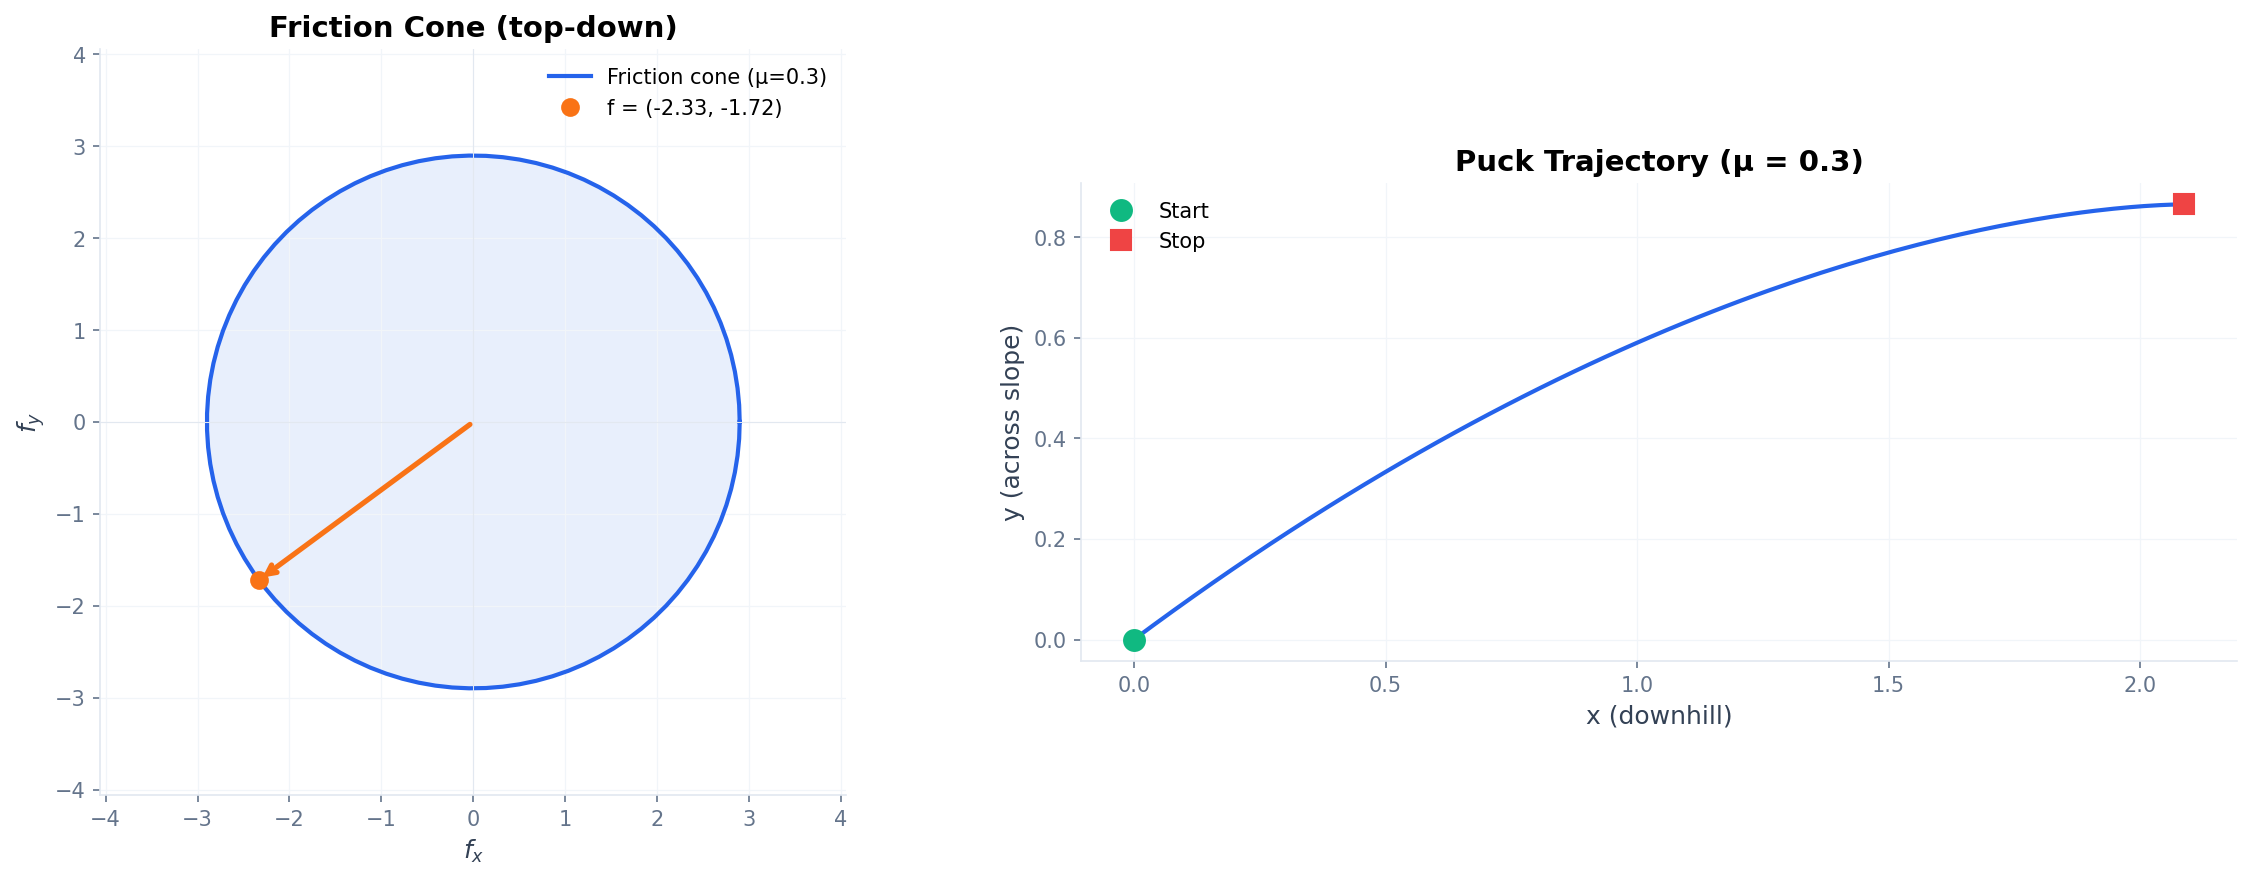

In [2]:
# --- CVXPY single-step contact solve ---
v0 = np.array([2.0, 1.5])

f_var = cp.Variable(2)
v_free = v0 + h * F_ext
v_next = v_free + h * f_var

objective = cp.Minimize(0.5 * cp.sum_squares(v_next))
constraints = [cp.SOC(mu_true * f_n, f_var)]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.MOREAU)

print(f"Status: {prob.status}")
print(f"Friction force: ({f_var.value[0]:.4f}, {f_var.value[1]:.4f})")
print(f"Friction magnitude: {np.linalg.norm(f_var.value):.4f}")
print(f"Friction limit μ·f_n: {mu_true * f_n:.4f}")

# --- Analytic verification ---
f_unconstrained = -v_free / h
if np.linalg.norm(f_unconstrained) <= mu_true * f_n:
    f_analytic = f_unconstrained
    print("\nAnalytic: puck stops (friction sufficient)")
else:
    f_analytic = -mu_true * f_n * v_free / np.linalg.norm(v_free)
    print("\nAnalytic: puck slides (friction at maximum)")

print(f"Analytic force: ({f_analytic[0]:.4f}, {f_analytic[1]:.4f})")
print(f"SOCP vs analytic error: {np.linalg.norm(f_var.value - f_analytic):.2e}")

# --- Simulate trajectory for visualization ---
def simulate_trajectory_np(v_init, mu, T=100):
    """Simulate puck trajectory using analytic cone projection."""
    positions = [np.array([0.0, 0.0])]
    velocities = [v_init.copy()]
    for t in range(T):
        v = velocities[-1]
        if np.linalg.norm(v) < 1e-10:
            positions.append(positions[-1].copy())
            velocities.append(np.zeros(2))
            continue
        vf = v + h * F_ext
        f_unc = -vf / h
        if np.linalg.norm(f_unc) <= mu * f_n:
            f = f_unc
        else:
            f = -mu * f_n * vf / np.linalg.norm(vf)
        v_new = vf + h * f
        pos_new = positions[-1] + dt * v_new
        velocities.append(v_new)
        positions.append(pos_new)
    return np.array(positions), np.array(velocities)

pos, vel = simulate_trajectory_np(np.array([2.0, 1.5]), mu_true, T=150)
speeds = np.linalg.norm(vel, axis=1)

# --- 2-panel visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Friction cone (top-down view) + force vector
ax = axes[0]
theta_circle = np.linspace(0, 2 * np.pi, 100)
cone_r = mu_true * f_n
ax.plot(cone_r * np.cos(theta_circle), cone_r * np.sin(theta_circle),
        color=MOREAU_COLORS['primary'], linewidth=2, label=f'Friction cone (μ={mu_true})')
ax.fill(cone_r * np.cos(theta_circle), cone_r * np.sin(theta_circle),
        color=MOREAU_COLORS['primary'], alpha=0.1)

f0_val = f_var.value
ax.annotate('', xy=(f0_val[0], f0_val[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=MOREAU_COLORS['accent'], linewidth=2.5))
ax.plot(f0_val[0], f0_val[1], 'o', color=MOREAU_COLORS['accent'], markersize=8,
        label=f'f = ({f0_val[0]:.2f}, {f0_val[1]:.2f})')

ax.set_xlim(-cone_r * 1.4, cone_r * 1.4)
ax.set_ylim(-cone_r * 1.4, cone_r * 1.4)
ax.set_aspect('equal')
ax.set_xlabel('$f_x$')
ax.set_ylabel('$f_y$')
ax.set_title('Friction Cone (top-down)', fontsize=14)
ax.legend(fontsize=10)
ax.axhline(0, color='#E2E8F0', linewidth=0.5)
ax.axvline(0, color='#E2E8F0', linewidth=0.5)

# Right: Puck trajectory on tilted surface
ax = axes[1]
ax.plot(pos[:, 0], pos[:, 1], color=MOREAU_COLORS['primary'], linewidth=2)
ax.plot(pos[0, 0], pos[0, 1], 'o', color=MOREAU_COLORS['success'],
        markersize=10, zorder=5, label='Start')
stop_idx = np.argmax(speeds[1:] < 1e-8) + 1 if np.any(speeds[1:] < 1e-8) else len(speeds) - 1
ax.plot(pos[stop_idx, 0], pos[stop_idx, 1], 's', color=MOREAU_COLORS['danger'],
        markersize=10, zorder=5, label='Stop')

ax.set_xlabel('x (downhill)')
ax.set_ylabel('y (across slope)')
ax.set_title(f'Puck Trajectory (μ = {mu_true})', fontsize=14)
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Why Smoothed Contact Fails

To learn $\mu$ by gradient descent, we need to differentiate through the contact simulation. The standard approach — used in MuJoCo and similar engines — is to **smooth** the hard cone projection:

$$f_{\text{smooth}} = -\mu f_n \cdot \frac{v_{\text{free}}}{\|v_{\text{free}}\| + \alpha}$$

This is differentiable everywhere, but the physics is **wrong**: friction vanishes at low speeds ($\|v_{\text{free}}\| \ll \alpha$), so pucks reach a terminal velocity instead of stopping. The optimizer finds a **biased** $\mu$ that compensates for the model error — it can never recover the true coefficient.

**`moreau.torch`** takes a different approach: solve the **exact** SOCP at each timestep, then differentiate via implicit differentiation of the KKT conditions. No smoothing, no approximation. The physics is correct, the gradients are correct, and the optimizer recovers the true $\mu$.

In [3]:
# --- Generate observed trajectories with mu_true ---
n_obs = 8
v_obs_inits = np.array([
    [1.5, 0.5], [1.0, -0.8], [0.8, 1.0], [-0.5, 1.5],
    [1.2, 0.3], [0.5, -1.2], [1.8, -0.3], [0.3, 0.8],
])

obs_positions = np.zeros((n_obs, T_learn + 1, 2))
obs_velocities = np.zeros((n_obs, T_learn + 1, 2))
obs_velocities[:, 0] = v_obs_inits

for i in range(n_obs):
    pos_i, vel_i = simulate_trajectory_np(v_obs_inits[i], mu_true, T=T_learn)
    obs_positions[i] = pos_i
    obs_velocities[i] = vel_i

obs_pos_t = torch.tensor(obs_positions, dtype=torch.float64)
v_obs_inits_t = torch.tensor(v_obs_inits, dtype=torch.float64)
F_ext_t = torch.tensor(F_ext, dtype=torch.float64)

stopped = np.linalg.norm(obs_velocities[:, -1], axis=1) < 1e-6
print(f"Generated {n_obs} observed trajectories (T={T_learn} steps)")
print(f"Pucks stopped by T={T_learn}: {stopped.sum()} / {n_obs}")


# --- Smoothed contact (MuJoCo-style) ---
def simulate_smoothed(mu_param, v_inits_t, T_sim, alpha=0.5):
    """f = -mu*f_n*v_free/(||v_free|| + alpha) — smooth but biased physics."""
    n = v_inits_t.shape[0]
    positions = [torch.zeros(n, 2, dtype=torch.float64)]
    velocities = [v_inits_t]

    for t in range(T_sim):
        v = velocities[-1]
        v_free = v + h * F_ext_t.unsqueeze(0)
        v_free_norm = torch.norm(v_free, dim=1, keepdim=True)
        f = -mu_param * f_n * v_free / (v_free_norm + alpha)

        v_new = v_free + h * f
        pos_new = positions[-1] + dt * v_new
        velocities.append(v_new)
        positions.append(pos_new)

    return torch.stack(positions, dim=1)


# --- moreau.torch (SOCP) ---
P_sp = sparse.csr_array(h**2 * sparse.eye(2, format='csr'))
P_sp.sort_indices()
P_ro, P_ci, P_vals = sparse_to_csr(P_sp)

A_sp = sparse.csr_array(np.array([[0.0, 0.0], [-1.0, 0.0], [0.0, -1.0]]))
A_sp.sort_indices()
A_ro, A_ci, A_vals = sparse_to_csr(A_sp)

n_vars, n_cons = 2, 3
cones = moreau.Cones(num_so_cones=1)

torch_solver = TorchSolver(
    n=n_vars, m=n_cons,
    P_row_offsets=torch.tensor(P_ro, dtype=torch.int64),
    P_col_indices=torch.tensor(P_ci, dtype=torch.int64),
    A_row_offsets=torch.tensor(A_ro, dtype=torch.int64),
    A_col_indices=torch.tensor(A_ci, dtype=torch.int64),
    cones=cones,
    settings=moreau.Settings(device='cpu', ipm_settings=moreau.IPMSettings(direct_solve_method='qdldl')),
)
P_vals_t = torch.tensor(P_vals, dtype=torch.float64)
A_vals_t = torch.tensor(A_vals, dtype=torch.float64)


def simulate_moreau(mu_param, v_inits_t, T_sim):
    """SOCP contact solve — exact physics + smooth implicit gradients."""
    n = v_inits_t.shape[0]
    positions = [torch.zeros(n, 2, dtype=torch.float64)]
    velocities = [v_inits_t]

    b = torch.stack([mu_param * f_n, torch.tensor(0.0, dtype=torch.float64),
                     torch.tensor(0.0, dtype=torch.float64)])

    for t in range(T_sim):
        v = velocities[-1]
        v_free = v + h * F_ext_t.unsqueeze(0)
        forces = []
        for i in range(n):
            q_i = h * v_free[i]
            sol_i = torch_solver.solve(P_vals_t, A_vals_t, q_i, b)
            forces.append(sol_i.x)
        f = torch.stack(forces)

        v_new = v_free + h * f
        pos_new = positions[-1] + dt * v_new
        velocities.append(v_new)
        positions.append(pos_new)

    return torch.stack(positions, dim=1)


print("Two simulators defined: smoothed, moreau")

Generated 8 observed trajectories (T=80 steps)
Pucks stopped by T=80: 8 / 8
Two simulators defined: smoothed, moreau


In [4]:
# --- Train both approaches ---
def train_approach(name, simulate_fn, n_epochs=200, lr=0.01):
    """Train mu via gradient descent through simulation."""
    mu_est = torch.tensor(0.1, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([mu_est], lr=lr)
    losses = []
    mu_history = [mu_est.item()]
    best_loss = float('inf')
    best_mu = mu_est.item()
    best_mu_history = [best_mu]

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        pred_pos = simulate_fn(mu_est, v_obs_inits_t, T_learn)
        loss = (pred_pos - obs_pos_t).pow(2).mean()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            mu_est.clamp_(min=0.01, max=1.0)

        cur_loss = loss.item()
        losses.append(cur_loss)
        mu_history.append(mu_est.item())
        if cur_loss < best_loss:
            best_loss = cur_loss
            best_mu = mu_est.item()
        best_mu_history.append(best_mu)

        if (epoch + 1) % 50 == 0:
            print(f"  {name} epoch {epoch+1:3d}: loss={cur_loss:.6f}  μ={mu_est.item():.4f}  best_μ={best_mu:.4f}")

    best_losses = []
    running_best = float('inf')
    for l in losses:
        running_best = min(running_best, l)
        best_losses.append(running_best)

    return best_losses, mu_history, best_mu_history

print("Training smoothed contact (MuJoCo-style, alpha=0.5)...")
losses_smoothed, mu_hist_smoothed, best_mu_hist_smoothed = train_approach("smoothed", simulate_smoothed)

print("\nTraining moreau.torch (SOCP)...")
losses_moreau, mu_hist_moreau, best_mu_hist_moreau = train_approach("moreau", simulate_moreau)

print(f"\n{'Approach':<25} {'Best μ':>10} {'Error':>10}")
print("-" * 47)
for name, best_hist in [("Smoothed (MuJoCo)", best_mu_hist_smoothed),
                        ("moreau.torch", best_mu_hist_moreau)]:
    err = abs(best_hist[-1] - mu_true) / mu_true * 100
    print(f"{name:<25} {best_hist[-1]:10.4f} {err:9.2f}%")

Training smoothed contact (MuJoCo-style, alpha=0.5)...


  smoothed epoch  50: loss=0.013828  μ=0.4252  best_μ=0.4252


  smoothed epoch 100: loss=0.007319  μ=0.4756  best_μ=0.4756


  smoothed epoch 150: loss=0.007030  μ=0.4873  best_μ=0.4873


  smoothed epoch 200: loss=0.007010  μ=0.4907  best_μ=0.4907

Training moreau.torch (SOCP)...


  moreau epoch  50: loss=0.002942  μ=0.3245  best_μ=0.3024


  moreau epoch 100: loss=0.000022  μ=0.2981  best_μ=0.2996


  moreau epoch 150: loss=0.000000  μ=0.3001  best_μ=0.3001


  moreau epoch 200: loss=0.000000  μ=0.3000  best_μ=0.3000

Approach                      Best μ      Error
-----------------------------------------------
Smoothed (MuJoCo)             0.4907     63.55%
moreau.torch                  0.3000      0.00%


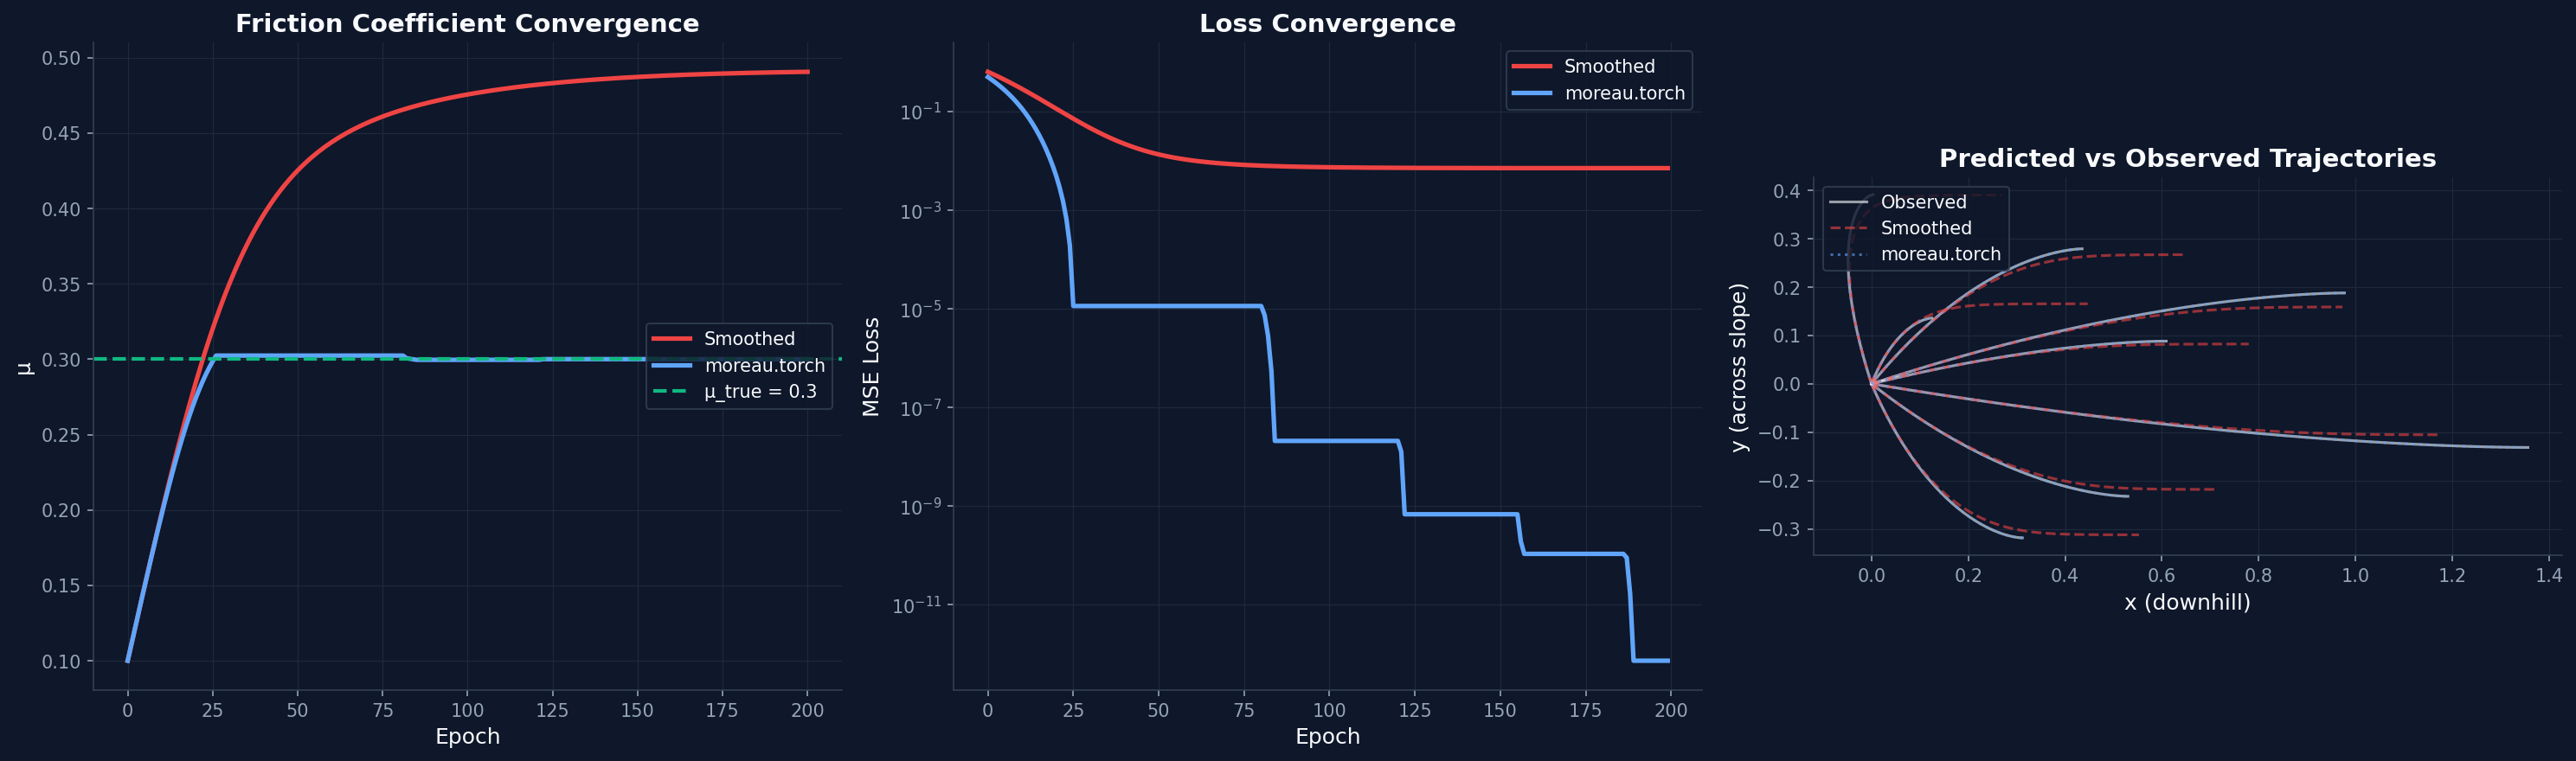

Saved hero image to ../assets/contact_friction.png


In [5]:
# --- Generate final predictions for visualization ---
with torch.no_grad():
    pred_smoothed = simulate_smoothed(
        torch.tensor(best_mu_hist_smoothed[-1], dtype=torch.float64),
        v_obs_inits_t, T_learn).numpy()
    pred_moreau = simulate_moreau(
        torch.tensor(best_mu_hist_moreau[-1], dtype=torch.float64),
        v_obs_inits_t, T_learn).numpy()

# --- Hero image: dark, 3-panel ---
set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

approach_styles = [
    ('Smoothed', MOREAU_COLORS['danger'], best_mu_hist_smoothed, losses_smoothed),
    ('moreau.torch', MOREAU_COLORS['primary_light'], best_mu_hist_moreau, losses_moreau),
]

# Panel 1: μ convergence
ax = axes[0]
for name, color, hist, _ in approach_styles:
    ax.plot(range(len(hist)), hist, color=color, linewidth=2.5, label=name)
ax.axhline(mu_true, color=MOREAU_COLORS['success'], linestyle='--', linewidth=2,
           label=f'μ_true = {mu_true}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('μ', fontsize=12)
ax.set_title('Friction Coefficient Convergence', fontsize=14)
ax.legend(loc='center right', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155', fontsize=10)

# Panel 2: Loss curves (log scale)
ax = axes[1]
for name, color, _, loss_hist in approach_styles:
    ax.semilogy(loss_hist, color=color, linewidth=2.5, label=name)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Loss Convergence', fontsize=14)
ax.legend(loc='upper right', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155', fontsize=10)

# Panel 3: Trajectories for all pucks
ax = axes[2]
for i in range(n_obs):
    label_obs = 'Observed' if i == 0 else None
    label_sm = 'Smoothed' if i == 0 else None
    label_mo = 'moreau.torch' if i == 0 else None
    ax.plot(obs_positions[i, :, 0], obs_positions[i, :, 1],
            color=MOREAU_COLORS['text'], linewidth=1.5, alpha=0.6, label=label_obs)
    ax.plot(pred_smoothed[i, :, 0], pred_smoothed[i, :, 1],
            color=MOREAU_COLORS['danger'], linewidth=1.5, alpha=0.6,
            linestyle='--', label=label_sm)
    ax.plot(pred_moreau[i, :, 0], pred_moreau[i, :, 1],
            color=MOREAU_COLORS['primary_light'], linewidth=1.5, alpha=0.6,
            linestyle=':', label=label_mo)

ax.set_xlabel('x (downhill)', fontsize=12)
ax.set_ylabel('y (across slope)', fontsize=12)
ax.set_title('Predicted vs Observed Trajectories', fontsize=14)
ax.set_aspect('equal')
ax.legend(loc='upper left', frameon=True, facecolor=MOREAU_COLORS['bg_dark'],
          edgecolor='#334155', fontsize=10)

plt.tight_layout()
plt.savefig('../assets/contact_friction.png', bbox_inches='tight',
            facecolor=MOREAU_COLORS['bg_dark'])
plt.show()
set_moreau_style()
print("Saved hero image to ../assets/contact_friction.png")

---

**Key takeaways:**

| | Physics | Gradients | Result |
|---|---|---|---|
| **Smoothed (MuJoCo)** | Biased — friction vanishes at low speed | Smooth | Converges to **wrong** μ |
| **`moreau.torch`** | Exact — solves the true SOCP | Smooth (implicit diff) | Converges to **correct** μ |

- **Friction cones are SOC3** — `||(f_x, f_y)|| ≤ μ·f_n` maps directly to `Cones(num_so_cones=1)`, the most natural second-order cone in physics
- **Smoothing introduces bias** — replacing the hard cone projection with a soft approximation gives differentiable gradients, but the wrong physics. The optimizer finds a μ that compensates for the model error, not the true μ
- **moreau.torch** — no smoothing, no ε, no manual projection. Formulate the SOCP, and the solver handles both the forward solve and the backward pass correctly